<a href="https://colab.research.google.com/github/bulut19/real-time-flight-tracking/blob/main/real_time_flight_tracking_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Real-Time Flight Tracking Pipeline

An end-to-end data engineering and ML pipeline on Google Cloud, progressing from historical batch analysis to true real-time streaming predictions on live flight data.

**Three-part architecture:**

1. **Batch processing (historical data).** Download, clean, and load historical U.S. flight performance data into BigQuery, then train and evaluate three BigQuery ML models (linear regression, logistic regression, K-means clustering) on it.
2. **Micro-batch ingestion (live data, polled).** Pull live flight state vectors from the OpenSky Network API on a schedule, land them in Cloud Storage, and load them into BigQuery, then retrain the same class of models on real-time-sourced data.
3. **True real-time streaming.** A Pub/Sub producer/consumer architecture: a producer publishes live OpenSky flight states to a Pub/Sub topic, and a subscriber pulls each message, inserts it into BigQuery, and immediately runs `ML.PREDICT` against it, turning individual flight events into predictions with no batch delay.

Each part builds on the last: the same modeling questions (predict flight velocity, classify on-ground status) get progressively less batch latency, from a static historical dataset, to periodic polling, to per-event streaming inference.

## Part I: Batch Processing of Historical Flight Data

Builds a foundational pipeline on a large, static dataset: U.S. domestic flight on-time performance data (BTS.gov, 2024). Downloads and cleans the raw data, loads it into BigQuery, and trains three BigQuery ML models to predict and segment arrival delays.

In [ ]:
# @title ### Cell 1: Setup, Authentication, and Configuration (Corrected)
# @markdown **Objective:** This cell imports all necessary Python libraries, authenticates your Google account to allow access to your GCP project, and sets up key configuration variables.

# ---
# **Libraries Explained:**
# - `os`: For interacting with the operating system, like removing files.
# - `requests`: A standard library for making HTTP requests to download files from the web.
# - `zipfile`: For working with ZIP archives, allowing us to extract the downloaded data.
# - `subprocess`: Allows us to run shell commands like `gcloud` and `gsutil` directly from Python.
# - `re`: The regular expressions library, used here for cleaning text data.
# - `datetime`: For handling dates and looping through the required time period.
# - `google.colab.auth`: A specific Colab library to handle authentication with your Google account.
# ---

import os
import requests
import zipfile
import subprocess
import re
from datetime import datetime
from google.colab import auth

def setup_environment():
    """
    Authenticates the user and configures the necessary GCP project and bucket names.

    This function handles the initial setup by authenticating the user's Google account
    for use within the Colab environment. It then programmatically determines the
    current GCP Project ID. If it cannot be determined automatically, it will prompt
    the user to enter it manually. It also prompts the user for a base bucket name
    and combines it with the project ID to ensure global uniqueness.

    Returns:
        tuple: A tuple containing the Project ID and the generated GCS bucket name.
               Returns (None, None) if the project ID or bucket name is not provided.
    """
    print("Authenticating your Google account...")
    # This command will trigger a pop-up to authenticate your Google account.
    auth.authenticate_user()
    print("✅ Authentication successful.")

    project_id = ""
    try:
        # This command runs the gcloud CLI to get the currently configured project ID.
        project_id_process = subprocess.run(
            ["gcloud", "config", "get-value", "project"],
            capture_output=True, text=True, check=True
        )
        project_id = project_id_process.stdout.strip()
    except (subprocess.CalledProcessError, FileNotFoundError):
        # This block will run if gcloud is not configured or not found.
        pass

    if not project_id:
        print("⚠️ Could not automatically determine GCP Project ID.")
        project_id = input("Please enter your GCP Project ID: ")

    if not project_id:
        print("🔴 ERROR: Project ID is required to continue. Halting execution.")
        return None, None

    print(f"✅ Using GCP Project: {project_id}")

    # --- EDIT: Ask for the bucket name from the user ---
    base_bucket_name = input("Please enter a base name for your GCS bucket (e.g., 'flight-data'): ")
    if not base_bucket_name:
        print("🔴 ERROR: A base name for the bucket is required. Halting execution.")
        return project_id, None

    # GCS bucket names must be globally unique and cannot contain dots or start with underscores.
    # We create a safe, unique name by combining the project ID and the user's input.
    safe_project_id = project_id.replace('.', '-')
    bucket_name = f"{safe_project_id}-{base_bucket_name}"
    print(f"✅ Bucket will be named: {bucket_name}")
    return project_id, bucket_name

# Run the setup function and store the variables.
PROJECT_ID, BUCKET_NAME = setup_environment()

Authenticating your Google account...
✅ Authentication successful.
⚠️ Could not automatically determine GCP Project ID.
Please enter your GCP Project ID: YOUR_PROJECT_ID
✅ Using GCP Project: YOUR_PROJECT_ID
Please enter a base name for your GCS bucket (e.g., 'flight-data'): flight-data
✅ Bucket will be named: YOUR_PROJECT_ID-flight-data


In [ ]:
# @title ### Cell 2: Create GCS Bucket (Corrected)
# @markdown **Objective:** This cell checks if the required Google Cloud Storage (GCS) bucket exists, and if not, it creates it.

def create_gcs_bucket_if_not_exists(bucket_name, project_id):
    """
    Checks for the existence of a GCS bucket and creates it if it's not found.

    This function uses the `gsutil` command-line tool to interact with GCS.
    It first tries to list the contents of the target bucket. If this command
    fails, it assumes the bucket does not exist and proceeds to create it
    using `gsutil mb` (make bucket).

    Args:
        bucket_name (str): The name of the GCS bucket to check and create.
        project_id (str): The GCP project ID to associate with the bucket creation.
    """
    if not bucket_name or not project_id:
        print("🔴 ERROR: Bucket name or Project ID is not set. Cannot proceed.")
        return

    print(f"\nChecking for GCS bucket: gs://{bucket_name}")
    try:
        # The `gsutil ls` command will fail if the bucket does not exist.
        subprocess.run(["gsutil", "ls", f"gs://{bucket_name}"], check=True, capture_output=True)
        print(f"✅ Bucket gs://{bucket_name} already exists.")
    except subprocess.CalledProcessError:
        print(f"Bucket not found. Creating gs://{bucket_name}...")
        # `gsutil mb` creates a new bucket.
        try:
            # --- FIX: Added the '-p [project_id]' flag to the gsutil command ---
            subprocess.run(
                ["gsutil", "mb", "-p", project_id, f"gs://{bucket_name}"],
                check=True, capture_output=True, text=True
            )
            print(f"✅ Bucket gs://{bucket_name} created.")
        except subprocess.CalledProcessError as e:
            print(f"🔴 ERROR: Failed to create bucket. The name may be taken or invalid.")
            print(f"   Details: {e.stderr}")


# Run the bucket creation function using the globally defined variables.
create_gcs_bucket_if_not_exists(BUCKET_NAME, PROJECT_ID)


Checking for GCS bucket: gs://YOUR_PROJECT_ID-flight-data
✅ Bucket gs://YOUR_PROJECT_ID-flight-data already exists.


In [ ]:
# @title ### Cell 3: Define the Data Download and Preparation Function
# @markdown **Objective:** This cell defines the main worker function, `download_and_prepare_month`, which handles the entire ETL (Extract, Transform, Load) process for a single month's data.

def download_and_prepare_month(year, month, bucket_name):
    """
    Downloads, unzips, cleans, and uploads data for a specific month and year.

    This function encapsulates the logic from the shell script's `prepareMonthData`
    function, performing the following steps:
    1.  Constructs the download URL and downloads the ZIP file using `requests`.
    2.  Extracts the contents of the ZIP file using `zipfile`.
    3.  Finds the specific CSV file for the month and cleans it by removing
        trailing commas and all quotation marks, replicating the `sed` commands.
    4.  Uploads the cleaned CSV file to a specific folder within the GCS bucket.
    5.  Cleans up all temporary local files.

    Args:
        year (int): The year of the data to download.
        month (int): The month of the data to download.
        bucket_name (str): The GCS bucket to upload the final data to.
    """
    print(f"\n--- Preparing data for {month:02d}/{year} ---")

    # 1. Download the data file from BTS.gov
    print("  Downloading...")
    url = f"https://transtats.bts.gov/PREZIP/On_Time_Reporting_Carrier_On_Time_Performance_1987_present_{year}_{month}.zip"
    downloaded_zip_file = f"{year}-{month}.zip"

    try:
        # We use requests.get() to download the file.
        # `verify=False` is used to bypass potential SSL certificate issues, similar to `curl -k`.
        response = requests.get(url, verify=False, timeout=300)
        response.raise_for_status()  # This will raise an HTTPError for bad responses (4xx or 5xx)
        with open(downloaded_zip_file, 'wb') as f:
            f.write(response.content)
    except requests.exceptions.RequestException as e:
        print(f"  🔴 ERROR: Cannot download data for {month}/{year}. URL may be invalid or server is down. {e}")
        return

    # 2. Unzip the downloaded file
    print("  Unzipping...")
    try:
        with zipfile.ZipFile(downloaded_zip_file, 'r') as zip_ref:
            zip_ref.extractall(".")
    except zipfile.BadZipFile:
        print(f"  🔴 ERROR: Failed to unzip file for {month}/{year}. It may not be a valid zip archive.")
        if os.path.exists(downloaded_zip_file):
            os.remove(downloaded_zip_file)
        return

    # 3. Clean the extracted CSV data
    print("  Cleaning...")
    cleaned_csv_file = f"{year}-{month}.csv"
    original_csv_name = None
    # Find the CSV file that was just unzipped.
    for file in os.listdir("."):
        if file.endswith(f"_{year}_{month}.csv"):
            original_csv_name = file
            break

    if not original_csv_name:
        print(f"  🔴 ERROR: No CSV file found after unzipping for {month}/{year}.")
        if os.path.exists(downloaded_zip_file): os.remove(downloaded_zip_file)
        return

    # Read the original file, clean each line, and write to a new file.
    with open(original_csv_name, 'r', encoding='utf-8', errors='ignore') as infile, \
         open(cleaned_csv_file, 'w', encoding='utf-8') as outfile:
        for line in infile:
            # Replicates `sed -e 's/,$//g' -e 's/"//g'`
            # 1. Remove trailing comma if it exists.
            # 2. Remove all quotation marks.
            cleaned_line = re.sub(r',?$', '', line.strip()).replace('"', '')
            outfile.write(cleaned_line + '\n')

    # 4. Upload the cleaned file to Google Cloud Storage
    print("  Storing in GCS...")
    destination_blob_name = f"data/flightsETL/{cleaned_csv_file}"
    try:
        # Use `gsutil cp` to copy the local file to the GCS bucket.
        subprocess.run(
            ["gsutil", "cp", cleaned_csv_file, f"gs://{bucket_name}/{destination_blob_name}"],
            check=True, capture_output=True
        )
        print(f"  ✅ Successfully uploaded {cleaned_csv_file}")
    except subprocess.CalledProcessError as e:
        print(f"  🔴 ERROR: Failed to upload to GCS. {e.stderr.decode()}")

    # 5. Clean up all local files to save space
    print("  Cleaning up local files...")
    if os.path.exists(downloaded_zip_file): os.remove(downloaded_zip_file)
    if os.path.exists(original_csv_name): os.remove(original_csv_name)
    if os.path.exists(cleaned_csv_file): os.remove(cleaned_csv_file)
    # Also remove any other potential extracted files like readme.html
    if os.path.exists("readme.html"): os.remove("readme.html")

In [ ]:
# @title ### Cell 4: Main Execution Loop
# @markdown **Objective:** This cell defines the date range for the data download and then loops through each month, calling the worker function defined in the previous cell.

def run_pipeline():
    """
    Manages the overall execution flow. It sets the date range and iterates
    through each month, calling the data preparation function.
    """
    if not BUCKET_NAME:
        print("🔴 ERROR: BUCKET_NAME is not defined. Halting execution.")
        return

    # --- Define Date Range ---
    # You can change these values to download a different range of data.
    start_year, start_month = 2024, 1  # Start: January 2024
    end_year, end_month = 2024, 3      # End: March 2024

    print(f"Starting pipeline to download data from {start_month}/{start_year} to {end_month}/{end_year}.")

    # --- Loop Through Dates ---
    current_date = datetime(start_year, start_month, 1)
    end_date = datetime(end_year, end_month, 1)

    while current_date <= end_date:
        download_and_prepare_month(current_date.year, current_date.month, BUCKET_NAME)

        # Increment the date to the next month
        # This logic correctly handles rolling over to the next year.
        next_month = current_date.month + 1
        next_year = current_date.year
        if next_month > 12:
            next_month = 1
            next_year += 1
        current_date = datetime(next_year, next_month, 1)

    print("\n--- Pipeline Execution Complete ---")

# Execute the main pipeline function.
run_pipeline()

Starting pipeline to download data from 1/2024 to 3/2024.

--- Preparing data for 01/2024 ---
  Downloading...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'transtats.bts.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  Unzipping...
  Cleaning...
  Storing in GCS...
  ✅ Successfully uploaded 2024-1.csv
  Cleaning up local files...

--- Preparing data for 02/2024 ---
  Downloading...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'transtats.bts.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  Unzipping...
  Cleaning...
  Storing in GCS...
  ✅ Successfully uploaded 2024-2.csv
  Cleaning up local files...

--- Preparing data for 03/2024 ---
  Downloading...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'transtats.bts.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  Unzipping...
  Cleaning...
  Storing in GCS...
  ✅ Successfully uploaded 2024-3.csv
  Cleaning up local files...

--- Pipeline Execution Complete ---


In [ ]:
# @title ### Cell 5: Final Verification
# @markdown **Objective:** This final cell runs the `gsutil ls -l` command to list the contents of the target GCS directory. This allows you to verify that all the cleaned CSV files were successfully uploaded.

def verify_uploads(bucket_name):
    """
    Lists the final contents of the target GCS directory to verify uploads.
    """
    if not bucket_name:
        print("🔴 ERROR: BUCKET_NAME is not defined. Cannot verify.")
        return

    target_directory = f"gs://{bucket_name}/data/flightsETL/"
    print(f"\nVerifying final contents of {target_directory}...")

    try:
        # Use subprocess to run the gsutil command and capture its output.
        result = subprocess.run(
            ["gsutil", "ls", "-l", target_directory],
            check=True, capture_output=True, text=True
        )
        print("✅ Uploads confirmed:")
        print(result.stdout)
    except subprocess.CalledProcessError as e:
        print(f"🔴 ERROR: Could not list directory contents. It may be empty or there was an error.")
        print(e.stderr)

# Run the verification function.
verify_uploads(BUCKET_NAME)


Verifying final contents of gs://YOUR_PROJECT_ID-flight-data/data/flightsETL/...
✅ Uploads confirmed:
 198123150  2025-11-18T21:58:58Z  gs://YOUR_PROJECT_ID-flight-data/data/flightsETL/2024-1.csv
 188194543  2025-11-18T21:59:29Z  gs://YOUR_PROJECT_ID-flight-data/data/flightsETL/2024-2.csv
 215000314  2025-11-18T22:00:03Z  gs://YOUR_PROJECT_ID-flight-data/data/flightsETL/2024-3.csv
TOTAL: 3 objects, 601318007 bytes (573.46 MiB)



In [ ]:
# @title ### Cell 6: Create BigQuery Dataset
# @markdown **Objective:** This cell creates a new dataset in BigQuery to store our flight data. A dataset is a container for your tables, similar to a schema in a traditional database.

from google.cloud import bigquery
from google.cloud.exceptions import Conflict

# Initialize the BigQuery client
client = bigquery.Client(project=PROJECT_ID)

# Define the name for your new BigQuery dataset
BIGQUERY_DATASET = "flights_data"
dataset_id = f"{PROJECT_ID}.{BIGQUERY_DATASET}"

try:
    # Create a Dataset object
    dataset = bigquery.Dataset(dataset_id)
    # Specify the location for the dataset
    dataset.location = "US" # You can change this to your preferred location
    # Make an API request to create the dataset
    client.create_dataset(dataset, timeout=30)
    print(f"✅ Successfully created dataset: {dataset_id}")
except Conflict:
    print(f"✅ Dataset '{dataset_id}' already exists.")
except Exception as e:
    print(f"🔴 An error occurred: {e}")

✅ Dataset 'YOUR_PROJECT_ID.flights_data' already exists.


In [ ]:
# @title ### Cell 7: Load All CSVs from GCS into a BigQuery Table
# @markdown **Objective:** This cell uses a BigQuery Load Job to efficiently load all the cleaned CSV files from your GCS bucket into a single BigQuery table. This is the recommended method for batch loading from GCS.

# Define the name for the new table
BIGQUERY_TABLE = "flights_raw"
table_id = f"{PROJECT_ID}.{BIGQUERY_DATASET}.{BIGQUERY_TABLE}"

# Configure the Load Job
job_config = bigquery.LoadJobConfig(
    # Automatically infer the schema from the data.
    autodetect=True,
    # Skip the first row of each file, which contains the headers.
    skip_leading_rows=1,
    # The source format is CSV.
    source_format=bigquery.SourceFormat.CSV,
    # Allow for rows that might have too few columns.
    allow_jagged_rows=True,
    # Overwrite the table if it already exists.
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,
)

# Define the GCS URI using a wildcard to select all CSV files in the folder
uri = f"gs://{BUCKET_NAME}/data/flightsETL/*.csv"

try:
    # Start the Load Job
    load_job = client.load_table_from_uri(
        uri, table_id, job_config=job_config
    )
    print(f"🚀 Starting BigQuery load job {load_job.job_id}...")

    # Waits for the job to complete.
    load_job.result()
    print("✅ Load job finished.")

    # Get the destination table object and print the row count
    destination_table = client.get_table(table_id)
    print(f"Loaded {destination_table.num_rows} rows into table '{BIGQUERY_TABLE}'.")

except Exception as e:
    print(f"🔴 An error occurred: {e}")

🚀 Starting BigQuery load job ab871e83-b5ab-44c2-83ed-b20179c7dd93...
✅ Load job finished.
Loaded 1658259 rows into table 'flights_raw'.


In [ ]:
# @title ### Cell 8: Data Cleaning and Feature Engineering (Corrected)
# @markdown **Objective:** This cell runs a SQL query to create a new, cleaned view of our data. This view will serve as the basis for our machine learning models. We will create a key boolean label, `is_arrival_delayed`, for our classification model.

# Define the name for our new view
CLEANED_VIEW = "flights_cleaned"
view_id = f"{PROJECT_ID}.{BIGQUERY_DATASET}.{CLEANED_VIEW}"

# This SQL query selects relevant columns and creates our new feature.
# A VIEW is a virtual table based on the result-set of an SQL statement.
# It's a great way to create a clean dataset without duplicating data.
# --- FIX: Using the correct column names from the provided schema ---
sql_query = f"""
CREATE OR REPLACE VIEW `{view_id}` AS
SELECT
  -- Construct a DATE type from Year, Month, DayofMonth columns
  PARSE_DATE('%Y%m%d', CONCAT(CAST(Year AS STRING), LPAD(CAST(Month AS STRING), 2, '0'), LPAD(CAST(DayofMonth AS STRING), 2, '0'))) AS FL_DATE,
  IATA_CODE_Reporting_Airline AS CARRIER,
  Origin,
  Dest,
  DepDelay,
  ArrDelay,
  Distance,
  CAST(DayOfWeek AS STRING) AS DAY_OF_WEEK,
  -- Create a boolean label: TRUE if arrival delay is > 15 mins, FALSE otherwise.
  -- We also treat NULL delays as not delayed.
  CASE
    WHEN ArrDelay > 15 THEN TRUE
    ELSE FALSE
  END AS is_arrival_delayed
FROM
  `{table_id}`
WHERE
  -- Filter out cancelled and diverted flights for accurate modeling
  Cancelled = 0 AND Diverted = 0;
"""

try:
    # Execute the query to create the view
    query_job = client.query(sql_query)
    query_job.result() # Wait for the job to complete
    print(f"✅ Successfully created cleaned view: {CLEANED_VIEW}")

    # Verify by showing the first 10 rows of the new view
    print("\n--- Sample of Cleaned Data ---")
    df = client.query(f"SELECT * FROM `{view_id}` LIMIT 10").to_dataframe()
    display(df)

except Exception as e:
    print(f"🔴 An error occurred: {e}")

✅ Successfully created cleaned view: flights_cleaned

--- Sample of Cleaned Data ---


,FL_DATE,CARRIER,Origin,Dest,DepDelay,ArrDelay,Distance,DAY_OF_WEEK,is_arrival_delayed
0,2024-02-12,9E,ABE,30397,600,826,128.0,1,True
1,2024-01-11,9E,ABE,30397,1734,1959,111.0,4,True
2,2024-01-14,9E,ABE,30397,1400,1620,127.0,7,True
3,2024-03-04,OH,ABE,31057,1925,2124,77.0,1,True
4,2024-03-11,G4,ABE,34761,1455,1732,134.0,1,True
5,2024-03-24,G4,ABE,34761,1505,1742,123.0,7,True
6,2024-03-13,G4,ABE,34761,1000,1237,122.0,3,True
7,2024-02-25,G4,ABE,34761,1503,1742,127.0,7,True
8,2024-02-28,MQ,ABI,30194,1818,1911,32.0,3,True
9,2024-02-22,MQ,ABI,30194,1029,1122,33.0,4,True


In [ ]:
# @title ### Cell 9: Build, Evaluate, and Predict with a Linear Regression Model
# @markdown **Objective:** Use BigQuery ML to create a linear regression model to predict the arrival delay (`ARR_DELAY`).

from google.cloud import bigquery
from google.cloud.exceptions import NotFound # Import NotFound for specific error handling

# Re-initialize the BigQuery client to ensure it's fresh and correctly scoped
client = bigquery.Client(project=PROJECT_ID)

# Re-define necessary variables as they might have been cleared
CLEANED_VIEW = "flights_cleaned"
view_id = f"{PROJECT_ID}.{BIGQUERY_DATASET}.{CLEANED_VIEW}"

print(f"Attempting to use view: {view_id}")

# --- Add a check for view existence before proceeding ---
try:
    client.get_table(view_id) # get_table works for views too
    print(f"✅ BigQuery view '{view_id}' confirmed to exist.")
except NotFound:
    print(f"🔴 ERROR: BigQuery view '{view_id}' not found. Please ensure Cell 8 (Data Cleaning and Feature Engineering) ran successfully and created the view.")
    raise # Re-raise the error to stop execution if the view is truly not found
except Exception as e:
    print(f"🔴 An unexpected error occurred while checking view existence: {e}")
    raise

# --- 1. Create the Linear Regression Model ---
print("🚀 Training Linear Regression model...")
create_linear_model_query = f"""
CREATE OR REPLACE MODEL `{PROJECT_ID}.{BIGQUERY_DATASET}.flight_delay_predictor`
OPTIONS(model_type='LINEAR_REG', input_label_cols=['ArrDelay']) AS
SELECT
  ArrDelay,
  DepDelay,
  CARRIER,
  Distance,
  DAY_OF_WEEK
FROM
  `{view_id}`;
"""
linear_job = client.query(create_linear_model_query)
linear_job.result()
print("✅ Linear Regression model created successfully.")

# --- 2. Evaluate the Model ---
print("\n--- Model Evaluation ---")
evaluate_linear_model_query = f"""
SELECT * FROM ML.EVALUATE(MODEL `{PROJECT_ID}.{BIGQUERY_DATASET}.flight_delay_predictor`);
"""
linear_eval_df = client.query(evaluate_linear_model_query).to_dataframe()
display(linear_eval_df)

# --- 3. Make Predictions with the Model ---
print("\n--- Sample Predictions ---")
predict_linear_query = f"""
SELECT
  ArrDelay AS actual_delay,
  predicted_ArrDelay
FROM
  ML.PREDICT(MODEL `{PROJECT_ID}.{BIGQUERY_DATASET}.flight_delay_predictor`,
    (SELECT * FROM `{view_id}` LIMIT 10));
"""
linear_predict_df = client.query(predict_linear_query).to_dataframe()
display(linear_predict_df)

Attempting to use view: YOUR_PROJECT_ID.flights_data.flights_cleaned
✅ BigQuery view 'YOUR_PROJECT_ID.flights_data.flights_cleaned' confirmed to exist.
🚀 Training Linear Regression model...
✅ Linear Regression model created successfully.

--- Model Evaluation ---


,mean_absolute_error,mean_squared_error,mean_squared_log_error,median_absolute_error,r2_score,explained_variance
0,192.550844,134107.363118,0.35035,127.854618,0.489373,0.48939



--- Sample Predictions ---


,actual_delay,predicted_ArrDelay
0,1447,1443.181999
1,930,1076.821569
2,1812,1729.948212
3,1835,1752.507022
4,734,980.201938
5,1539,1577.565394
6,1539,1570.016984
7,1128,1262.276273
8,1942,1871.884594
9,1539,1575.307499


In [ ]:
# @title ### Cell 10: Build, Evaluate, and Predict with a Logistic Regression Model
# @markdown **Objective:** Use BigQuery ML to create a logistic regression model to predict if a flight will be significantly delayed (`is_arrival_delayed`).

# --- 1. Create the Logistic Regression Model ---
print("🚀 Training Logistic Regression model...")
create_logistic_model_query = f"""
CREATE OR REPLACE MODEL `{PROJECT_ID}.{BIGQUERY_DATASET}.flight_delay_classifier`
OPTIONS(model_type='LOGISTIC_REG', input_label_cols=['is_arrival_delayed']) AS
SELECT
  *
FROM
  `{view_id}`;
"""
logistic_job = client.query(create_logistic_model_query)
logistic_job.result()
print("✅ Logistic Regression model created successfully.")

# --- 2. Evaluate the Model ---
print("\n--- Model Evaluation ---")
evaluate_logistic_model_query = f"""
SELECT * FROM ML.EVALUATE(MODEL `{PROJECT_ID}.{BIGQUERY_DATASET}.flight_delay_classifier`);
"""
logistic_eval_df = client.query(evaluate_logistic_model_query).to_dataframe()
display(logistic_eval_df)

# --- 3. Make Predictions with the Model ---
print("\n--- Sample Predictions ---")
# --- FIX: Changed 'prob' to the correct column name 'predicted_is_arrival_delayed_probs' ---
predict_logistic_query = f"""
SELECT
  is_arrival_delayed AS actual_is_delayed,
  predicted_is_arrival_delayed,
  predicted_is_arrival_delayed_probs
FROM
  ML.PREDICT(MODEL `{PROJECT_ID}.{BIGQUERY_DATASET}.flight_delay_classifier`,
    (SELECT * FROM `{view_id}` LIMIT 10))
"""
logistic_predict_df = client.query(predict_logistic_query).to_dataframe()
display(logistic_predict_df)

🚀 Training Logistic Regression model...
✅ Logistic Regression model created successfully.

--- Model Evaluation ---


,precision,recall,accuracy,f1_score,log_loss,roc_auc
0,0.996507,1.0,0.99651,0.998251,0.00973,0.996975



--- Sample Predictions ---


,actual_is_delayed,predicted_is_arrival_delayed,predicted_is_arrival_delayed_probs
0,True,True,"[{'label': True, 'prob': 0.9997520936530887}, ..."
1,True,True,"[{'label': True, 'prob': 0.9989382113697057}, ..."
2,True,True,"[{'label': True, 'prob': 0.9996965308361897}, ..."
3,True,True,"[{'label': True, 'prob': 0.9990455649499033}, ..."
4,True,True,"[{'label': True, 'prob': 0.9977062088039947}, ..."
5,True,True,"[{'label': True, 'prob': 0.9997205664663852}, ..."
6,True,True,"[{'label': True, 'prob': 0.9991476366196348}, ..."
7,True,True,"[{'label': True, 'prob': 0.9983670133345017}, ..."
8,True,True,"[{'label': True, 'prob': 0.9983232241482938}, ..."
9,True,True,"[{'label': True, 'prob': 0.9995967820128969}, ..."


In [ ]:
# @title ### Cell 11: Build and Analyze a K-Means Clustering Model
# @markdown **Objective:** Use BigQuery ML's K-Means to group flights into distinct clusters based on their characteristics.

# --- 1. Create the K-Means Clustering Model ---
print("🚀 Training K-Means Clustering model...")
create_kmeans_model_query = f"""
CREATE OR REPLACE MODEL `{PROJECT_ID}.{BIGQUERY_DATASET}.flight_clusterer`
OPTIONS(model_type='KMEANS', num_clusters=5) AS
SELECT
  DepDelay,
  ArrDelay,
  Distance
FROM
  `{view_id}`
WHERE DepDelay IS NOT NULL AND ArrDelay IS NOT NULL;
"""
kmeans_job = client.query(create_kmeans_model_query)
kmeans_job.result()
print("✅ K-Means Clustering model created successfully.")

# --- 2. Analyze the Cluster Centroids ---
print("\n--- Cluster Centroid Analysis ---")
# ML.CENTROIDS shows the average values for each feature within each cluster.
# This helps us understand what defines each cluster (e.g., Cluster 1 is short-haul flights with minor delays).
analyze_centroids_query = f"""
SELECT
  *
FROM
  ML.CENTROIDS(MODEL `{PROJECT_ID}.{BIGQUERY_DATASET}.flight_clusterer`);
"""
centroids_df = client.query(analyze_centroids_query).to_dataframe()
display(centroids_df)

# --- 3. See which Cluster Each Flight Belongs To ---
print("\n--- Sample Cluster Assignments ---")
predict_kmeans_query = f"""
SELECT
  CENTROID_ID,
  DepDelay,
  ArrDelay,
  Distance
FROM
  ML.PREDICT(MODEL `{PROJECT_ID}.{BIGQUERY_DATASET}.flight_clusterer`,
    (SELECT * FROM `{view_id}` LIMIT 10));
"""
kmeans_predict_df = client.query(predict_kmeans_query).to_dataframe()
display(kmeans_predict_df)

🚀 Training K-Means Clustering model...
✅ K-Means Clustering model created successfully.

--- Cluster Centroid Analysis ---


,centroid_id,feature,numerical_value,categorical_value
0,1,DepDelay,1387.068247,[]
1,1,ArrDelay,1414.476151,[]
2,1,Distance,76.558286,[]
3,2,DepDelay,1874.713209,[]
4,2,ArrDelay,2083.358549,[]
5,2,Distance,96.145750,[]
6,3,DepDelay,765.483292,[]
7,3,ArrDelay,971.163206,[]
8,3,Distance,103.571275,[]
9,4,DepDelay,1404.076196,[]



--- Sample Cluster Assignments ---


,CENTROID_ID,DepDelay,ArrDelay,Distance
0,1,2226,10,83.0
1,2,1710,1852,78.0
2,3,927,1154,119.0
3,5,1159,1425,124.0
4,3,931,1121,72.0
5,1,2220,4,65.0
6,2,2110,2311,104.0
7,3,955,1155,103.0
8,5,1000,1547,167.0
9,2,2105,2308,91.0


## Part II: Micro-Batch Processing of Live Data

Simulates a near-real-time environment: live flight state vectors are polled from the OpenSky Network API, landed in Cloud Storage, and loaded into BigQuery on each run, then the same modeling approach from Part I is retrained on this live-sourced data.

## Cell 1: Python packages and authentication

In [ ]:
R"""""
This cell installs required Python packages and authenticates the user to Google Cloud.

Packages installed:
- google-cloud-storage: For interacting with Google Cloud Storage.
- google-cloud-bigquery: For interacting with Google Cloud BigQuery.
- requests: A popular HTTP library.

Authentication:
The cell authenticates the user to Google Cloud, enabling access to Google Cloud Platform (GCP) services.
R"""""
!pip install google-cloud-storage google-cloud-bigquery requests

from google.colab import auth
print("Authenticating to Google Cloud...")
auth.authenticate_user()
print("Authentication successful.")

Authenticating to Google Cloud...
Authentication successful.


## Cell 2: Configure  project-specific variables and set the `gcloud` project.



In [ ]:
R"""
This cell configures essential project-specific variables for Google Cloud operations.

It defines:
- `PROJECT_ID`: The Google Cloud project ID.
- `GCP_REGION`: The Google Cloud region for services.
- `GCS_BUCKET_NAME`: The name of the Google Cloud Storage bucket.
- `GCS_FOLDER_PATH`: The folder path within the GCS bucket for data storage.
- `BQ_DATASET`: The BigQuery dataset name.
- `BQ_TABLE`: The BigQuery table name for flight data.
- `FLIGHT_RECORD_LIMIT`: A pipeline setting to limit records from the API.

Finally, it sets the `gcloud` project configuration to the specified `PROJECT_ID`.
R"""
# --- !! CONFIGURE YOUR VARIABLES !! ---

PROJECT_ID = "YOUR_PROJECT_ID"
GCP_REGION = "us-central1"  # Or the region you are using

# --- GCS Bucket (Source & Target) ---
GCS_BUCKET_NAME = "YOUR_BUCKET_NAME"
GCS_FOLDER_PATH = "opensky-data" # The folder you set in your scheduler

# --- BigQuery Table (Target) ---
BQ_DATASET = "training_dataset" # The dataset you created
BQ_TABLE = "flight-data"        # The table for flight data

# --- Pipeline Settings ---
FLIGHT_RECORD_LIMIT = 500 # How many records to pull from the API

# -------------------------------------

# Set the project for all gcloud commands
!gcloud config set project $PROJECT_ID

INFORMATION: Project 'YOUR_PROJECT_ID' has no 'environment' tag set. Use either 'Production', 'Development', 'Test', or 'Staging'. Add an 'environment' tag using `gcloud resource-manager tags bindings create`.
Updated property [core/project].


## Cell 4: Define the `OpenSkyApi` class and helper functions, initialize GCP clients, define the BigQuery schema, and implement the data pipeline logic.



In [ ]:
R"""
This cell defines the `OpenSkyApi` class for interacting with the OpenSky Network API,
along with several helper functions for data processing and a complete data pipeline.

Key functionalities include:
- **OpenSky API Integration**: Classes (`StateVector`, `OpenSkyStates`, `OpenSkyApi`)
  to fetch real-time flight data and handle API rate limits.
- **Data Parsing & Conversion**: Helper functions (`_convertTimestamp`, `_convert`, `_convertRow`)
  to clean and format raw API data into a structured dictionary for storage.
- **GCP Client Initialization**: Initializes `google.cloud.storage.Client` and
  `google.cloud.bigquery.Client` for interacting with Google Cloud Storage and BigQuery.
- **BigQuery Schema Definition**: Defines the explicit schema (`BQ_SCHEMA`) for the
  BigQuery `flight_data` table.
- **GCS to BigQuery Load Function**: `load_gcs_to_bigquery` handles loading JSONL files
  from GCS into a specified BigQuery table.
- **Full Pipeline Logic**: `run_full_pipeline_without_bq_load` orchestrates the process
  of fetching data from OpenSky API, processing it, and uploading it to a GCS bucket.

This cell effectively sets up all necessary components for data ingestion into GCP.
R"""
import os
import json
import logging
import datetime
import calendar
import time
import pprint
import requests
from collections import defaultdict
from google.cloud import storage, bigquery

# ==============================================================================
# OpenSky API Library Code
# ==============================================================================

logger = logging.getLogger('opensky_api')
logger.addHandler(logging.NullHandler())

class StateVector(object):
    keys = ["icao24", "callsign", "origin_country", "time_position",
            "last_contact", "longitude", "latitude", "baro_altitude", "on_ground",
            "velocity", "heading", "vertical_rate", "sensors",
            "geo_altitude", "squawk", "spi", "position_source"]
    def __init__(self, arr):
        self.__dict__ = dict(zip(StateVector.keys, arr))

class OpenSkyStates(object):
    def __init__(self, j):
        self.__dict__ = j
        if self.states is not None:
            self.states = [StateVector(a) for a in self.states]
        else:
            self.states = []

class OpenSkyApi(object):
    def __init__(self, username=None, password=None):
        self._auth = (username, password) if username else ()
        self._api_url = "https://opensky-network.org/api"
        self._last_requests = defaultdict(lambda: 0)

    def _get_json(self, url_post, callee, params=None):
        r = requests.get(f"{self._api_url}{url_post}",
                         auth=self._auth, params=params, timeout=60.00)
        if r.status_code == 200:
            self._last_requests[callee] = time.time()
            return r.json()
        logger.debug(f"Response not OK. Status {r.status_code} - {r.reason}")
        return None

    def _check_rate_limit(self, time_diff_noauth, time_diff_auth, func):
        if len(self._auth) < 2:
            return abs(time.time() - self._last_requests[func]) >= time_diff_noauth
        return abs(time.time() - self._last_requests[func]) >= time_diff_auth

    @staticmethod
    def _check_lat(lat):
        if not -90 <= lat <= 90:
            raise ValueError(f"Invalid latitude {lat}!")

    @staticmethod
    def _check_lon(lon):
        if not -180 <= lon <= 180:
            raise ValueError(f"Invalid longitude {lon}!")

    def get_states(self, time_secs=0, icao24=None, serials=None, bbox=()):
        if not self._check_rate_limit(10, 5, self.get_states):
            logger.debug("Blocking request due to rate limit")
            return None
        t = calendar.timegm(time_secs.timetuple()) if isinstance(time_secs, datetime.datetime) else int(time_secs)
        params = {"time": t, "icao24": icao24}
        if len(bbox) == 4:
            self._check_lat(bbox[0]); self._check_lat(bbox[1]); self._check_lon(bbox[2]); self._check_lon(bbox[3])
            params.update({"lamin": bbox[0], "lamax": bbox[1], "lomin": bbox[2], "lomax": bbox[3]})
        states_json = self._get_json("/states/all", self.get_states, params=params)
        return OpenSkyStates(states_json) if states_json else None

# ==============================================================================
# Data Parser Functions
# ==============================================================================

def _convertTimestamp(timestamp):
    if timestamp is not None:
        try:
            return datetime.datetime.fromtimestamp(timestamp).strftime('%Y-%m-%d %H:%M:%S')
        except: pass
    return None

def _convert(data,dataType):
    if data is not None:
        if dataType==str: return data.strip()
        try: return dataType(data)
        except: return None
    return None

def _convertRow(flightState, queryTime):
    row = {
        'icao24': _convert(flightState.icao24,str),
        'callsign': _convert(flightState.callsign,str),
        'origin': _convert(flightState.origin_country,str),
        'time':_convert( flightState.time_position,int),
        'contact':_convert( flightState.last_contact,int),
        'longitude':_convert( flightState.longitude,float),
        'latitude':_convert( flightState.latitude,float),
        'altitude':_convert( flightState.geo_altitude,float),
        'on_ground':_convert( flightState.on_ground,bool),
        'velocity':_convert( flightState.velocity,float),
        'heading':_convert( flightState.heading,float),
        'vertical_rate':_convert( flightState.vertical_rate,float),
        'sensors':_convert( flightState.sensors,str),
        'baro_altitude':_convert( flightState.baro_altitude,float),
        'squawk':_convert( flightState.squawk,int),
        'spi':_convert( flightState.spi,bool),
        'position_source':_convert( flightState.position_source,int)
    }
    time_bq = _convertTimestamp(flightState.time_position)
    if time_bq: row['time_bq'] = time_bq
    contact_bq = _convertTimestamp(flightState.last_contact)
    if contact_bq: row['contact_bq'] = contact_bq
    query_time_bq = _convertTimestamp(queryTime)
    if query_time_bq: row['query_time_bq'] = query_time_bq

    # Return only non-null values, as BQ handles missing fields
    return {k: v for k, v in row.items() if v is not None}

# Initialize GCP clients
storage_client = storage.Client(project=PROJECT_ID)
bq_client = bigquery.Client(project=PROJECT_ID)

# This is our robust, explicit schema
BQ_SCHEMA = [
    bigquery.SchemaField("icao24", "STRING"),
    bigquery.SchemaField("callsign", "STRING"),
    bigquery.SchemaField("origin", "STRING"),
    bigquery.SchemaField("time", "INTEGER"),
    bigquery.SchemaField("contact", "INTEGER"),
    bigquery.SchemaField("longitude", "FLOAT"),
    bigquery.SchemaField("latitude", "FLOAT"),
    bigquery.SchemaField("altitude", "FLOAT"),
    bigquery.SchemaField("on_ground", "BOOLEAN"),
    bigquery.SchemaField("velocity", "FLOAT"),
    bigquery.SchemaField("heading", "FLOAT"),
    bigquery.SchemaField("vertical_rate", "FLOAT"),
    bigquery.SchemaField("sensors", "STRING"),
    bigquery.SchemaField("baro_altitude", "FLOAT"),
    bigquery.SchemaField("squawk", "INTEGER"),
    bigquery.SchemaField("spi", "BOOLEAN"),
    bigquery.SchemaField("position_source", "INTEGER"),
    bigquery.SchemaField("time_bq", "TIMESTAMP"),
    bigquery.SchemaField("contact_bq", "TIMESTAMP"),
    bigquery.SchemaField("query_time_bq", "TIMESTAMP"),
]

def load_gcs_to_bigquery(gcs_uri, project_id, bq_dataset, bq_table, bq_schema, bq_client_instance):
    """Loads data from a GCS URI into a BigQuery table."""
    print(f"\nStep: Loading data from GCS into BigQuery...")
    print(f"  > Source: {gcs_uri}")
    print(f"  > Target: {bq_dataset}.{bq_table}")

    job_config = bigquery.LoadJobConfig()
    job_config.source_format = bigquery.SourceFormat.NEWLINE_DELIMITED_JSON
    job_config.schema = bq_schema
    job_config.autodetect = False
    job_config.write_disposition = bigquery.WriteDisposition.WRITE_APPEND

    load_job = bq_client_instance.load_table_from_uri(
        gcs_uri,
        f"{project_id}.{bq_dataset}.{bq_table}",
        job_config=job_config
    )

    print(f"  > Starting BQ Load Job: {load_job.job_id}")
    load_job.result()
    print(f"  > Job complete. Loaded {load_job.output_rows} rows.")
    print("✅ GCS to BigQuery Load Finished Successfully.")

def run_full_pipeline():
    """Executes the API -> GCS pipeline and returns GCS URI."""

    try:
        # ======================================================
        # 1. Download data from OpenSky API
        # ======================================================
        print(f"Step 1: Fetching up to {FLIGHT_RECORD_LIMIT} records from OpenSky API...")
        api = OpenSkyApi()
        queryTime = datetime.datetime.now().timestamp()
        flightStates = api.get_states()

        records = []
        if flightStates and flightStates.states:
            for state in flightStates.states:
                if len(records) >= FLIGHT_RECORD_LIMIT:
                    break
                records.append(_convertRow(state, queryTime))

        if not records:
            print("No flight data found. Exiting.")
            return None # Return None if no records

        print(f"  > Fetched {len(records)} records.")

        # ======================================================
        # 2. Save data to GCS Bucket
        # ======================================================
        local_filename = "flight_data.jsonl"
        with open(local_filename, 'w') as f:
            for record in records:
                f.write(json.dumps(record) + '\n')

        gcs_filename = f"{GCS_FOLDER_PATH}/colab_batch_{int(queryTime)}.jsonl"

        print(f"\nStep 2: Uploading data to GCS...")
        print(f"  > Source: {local_filename}")
        print(f"  > Destination: gs://{GCS_BUCKET_NAME}/{gcs_filename}")

        bucket = storage_client.bucket(GCS_BUCKET_NAME)
        blob = bucket.blob(gcs_filename)
        blob.upload_from_filename(local_filename)

        gcs_uri = f"gs://{GCS_BUCKET_NAME}/{gcs_filename}"
        print("  > Upload complete.")
        print("✅ API to GCS Pipeline Finished Successfully.")
        return gcs_uri # Return the GCS URI

    except Exception as e:
        print(f"\n❌ ERROR in pipeline: {e}")
        return None

print("✅ Main pipeline functions defined.")

✅ Main pipeline functions defined.


## Cell 6: Orchestrate the full data pipeline from API to GCS to BigQuery.



In [ ]:
print(f"--- Creating BigQuery Dataset '{BQ_DATASET}' ---")

try:
    dataset_id = f"{bq_client.project}.{BQ_DATASET}"
    dataset = bigquery.Dataset(dataset_id)
    dataset.location = GCP_REGION
    dataset = bq_client.create_dataset(dataset, timeout=30)  # Make an API request.
    print(f"✅ Dataset '{BQ_DATASET}' created in project '{bq_client.project}'.")
except Exception as e:
    if 'AlreadyExists' in str(e):
        print(f"⚠️ Dataset '{BQ_DATASET}' already exists. Skipping creation.")
    else:
        print(f"❌ Error creating dataset '{BQ_DATASET}': {e}")

--- Creating BigQuery Dataset 'training_dataset' ---
✅ Dataset 'training_dataset' created in project 'YOUR_PROJECT_ID'.


In [ ]:
R"""
This cell orchestrates the entire data pipeline, executing the following steps:
1.  **Run API to GCS Pipeline**: It calls `run_full_pipeline()` to fetch
    flight data from the OpenSky API and upload it as a JSONL file to a Google Cloud Storage bucket.
2.  **Load GCS to BigQuery**: If the GCS upload is successful, it then calls
    `load_gcs_to_bigquery()` to load the data from the GCS URI into the specified BigQuery table.

This ensures a complete data ingestion workflow from an external API to a data warehouse.
R"""
print("--- Running Full Data Pipeline (API -> GCS -> BigQuery) ---")

# 1. Execute API -> GCS pipeline
gcs_uri_for_bq_load = run_full_pipeline()

if gcs_uri_for_bq_load:
    # 2. Load data from GCS to BigQuery
    load_gcs_to_bigquery(
        gcs_uri_for_bq_load,
        PROJECT_ID,
        BQ_DATASET,
        BQ_TABLE,
        BQ_SCHEMA,
        bq_client
    )
    print("✅ Pipeline Finished Successfully.")
else:
    print("❌ Pipeline aborted: No data fetched or GCS upload failed.")

--- Running Full Data Pipeline (API -> GCS -> BigQuery) ---
Step 1: Fetching up to 500 records from OpenSky API...
  > Fetched 500 records.

Step 2: Uploading data to GCS...
  > Source: flight_data.jsonl
  > Destination: gs://YOUR_BUCKET_NAME/opensky-data/colab_batch_1763503327.jsonl
  > Upload complete.
✅ API to GCS Pipeline Finished Successfully.

Step: Loading data from GCS into BigQuery...
  > Source: gs://YOUR_BUCKET_NAME/opensky-data/colab_batch_1763503327.jsonl
  > Target: training_dataset.flight-data
  > Starting BQ Load Job: 4cfc1288-b0c2-43ef-8bed-74767689a816
  > Job complete. Loaded 500 rows.
✅ GCS to BigQuery Load Finished Successfully.
✅ Pipeline Finished Successfully.


## Cell 7: Create a BQML regression model to predict flight velocity.



In [ ]:
R"""
This cell creates a BigQuery ML (BQML) regression model.

Purpose:
- **Model Type**: Initializes a `LINEAR_REG` model.
- **Objective**: To predict `velocity` (the label) of flights.
- **Features**: Uses `altitude`, `vertical_rate`, and `heading` as input features.
- **Data Filtering**: Excludes `on_ground` flights (`on_ground = false`) to focus on airborne velocity prediction.
- **Output**: Stores the trained model in BigQuery at the path defined by `REGRESSION_MODEL_NAME`.

The cell also prints basic training statistics upon successful model creation.
R"""
print("--- Cell 6: Creating BQML Prediction (Regression) Model ---")

# Define the model name
REGRESSION_MODEL_NAME = "flight_velocity_predictor"
model_path = f"{PROJECT_ID}.{BQ_DATASET}.{REGRESSION_MODEL_NAME}"

# This SQL query creates a linear regression model.
# We are trying to PREDICT the 'velocity' (the LABEL)
# using 'altitude', 'vertical_rate', and 'heading' (the FEATURES).
# We also filter out any on-ground flights, as we only want to predict airborne velocity.

CREATE_PREDICTION_MODEL_QUERY = f"""
CREATE OR REPLACE MODEL `{model_path}`
OPTIONS(
    model_type='LINEAR_REG',
    input_label_cols=['velocity']
) AS
SELECT
    velocity,
    altitude,
    vertical_rate,
    heading
FROM
    `{PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE}`
WHERE
    velocity IS NOT NULL
    AND altitude IS NOT NULL
    AND vertical_rate IS NOT NULL
    AND heading IS NOT NULL
    AND on_ground = false
"""

print(f"Creating regression model at: {model_path}")
print("This may take a few minutes...")

# Run the BQML query
try:
    regression_job = bq_client.query(CREATE_PREDICTION_MODEL_QUERY)
    regression_job.result()  # Wait for the model training job to complete

    print(f"✅ Successfully created prediction model: {REGRESSION_MODEL_NAME}")

    # Optional: Get basic training stats
    stats_query = f"SELECT * FROM ML.TRAINING_INFO(MODEL `{model_path}`)"
    stats_job = bq_client.query(stats_query)
    for row in stats_job.result():
        print(f"  > Iteration {row['iteration']}: Loss = {row['loss']}")

except Exception as e:
    print(f"❌ Error creating regression model: {e}")

--- Cell 6: Creating BQML Prediction (Regression) Model ---
Creating regression model at: YOUR_PROJECT_ID.training_dataset.flight_velocity_predictor
This may take a few minutes...
✅ Successfully created prediction model: flight_velocity_predictor
  > Iteration 0: Loss = 1131.1686162701983


## Cell 8: Analyze `on_ground` label diversity in BigQuery

Investigate the distribution of the `on_ground` column in the `flight_data` BigQuery table to understand why the classification model failed due to insufficient label diversity.


In [ ]:
print("--- Analyzing 'on_ground' label diversity ---")

# Construct the SQL query to count distinct 'on_ground' values
ANALYZE_ON_GROUND_QUERY = f"""
SELECT
    on_ground,
    COUNT(*)
FROM
    `{PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE}`
GROUP BY
    on_ground
ORDER BY
    on_ground DESC
"""

print(f"Executing query to analyze 'on_ground' distribution:\n{ANALYZE_ON_GROUND_QUERY}")

# Execute the query
try:
    query_job = bq_client.query(ANALYZE_ON_GROUND_QUERY)
    results = query_job.result()  # Wait for the query to complete

    print("\nResults for 'on_ground' distribution:")
    found_true = False
    found_false = False
    for row in results:
        print(f"  on_ground: {row['on_ground']}, Count: {row['f0_']}")
        if row['on_ground'] is True:
            found_true = True
        if row['on_ground'] is False:
            found_false = True

    if found_true and found_false:
        print("✅ 'on_ground' column contains both TRUE and FALSE values. Label diversity is present.")
    elif found_true:
        print("❌ 'on_ground' column contains only TRUE values. Insufficient label diversity for classification.")
    elif found_false:
        print("❌ 'on_ground' column contains only FALSE values. Insufficient label diversity for classification.")
    else:
        print("⚠️ No data found for 'on_ground' column.")

except Exception as e:
    print(f"❌ Error analyzing 'on_ground' diversity: {e}")

--- Analyzing 'on_ground' label diversity ---
Executing query to analyze 'on_ground' distribution:

SELECT
    on_ground,
    COUNT(*)
FROM
    `YOUR_PROJECT_ID.training_dataset.flight-data`
GROUP BY
    on_ground
ORDER BY
    on_ground DESC


Results for 'on_ground' distribution:
  on_ground: True, Count: 43
  on_ground: False, Count: 457
✅ 'on_ground' column contains both TRUE and FALSE values. Label diversity is present.


## Cell 9: Create a BQML classification model to predict whether a flight is on the ground.



In [ ]:
R"""
This cell creates a BigQuery ML (BQML) classification model.

Purpose:
- **Model Type**: Initializes a `LOGISTIC_REG` model.
- **Objective**: To classify whether a flight is `on_ground` (the label).
- **Features**: Uses `altitude` and `velocity` as input features.
- **Data Split Method**: Uses `NO_SPLIT` to ensure the model trains on all available data,
  which is crucial for the classification task to see both 'true' and 'false' labels.
- **Output**: Stores the trained model in BigQuery at the path defined by `CLASSIFICATION_MODEL_NAME`.

The cell also prints basic training statistics upon successful model creation.
R"""


print("\n--- Creating BQML Classification Model (with NULL handling) ---")

# Define the model name
CLASSIFICATION_MODEL_NAME = "flight_on_ground_classifier"
model_path = f"{PROJECT_ID}.{BQ_DATASET}.{CLASSIFICATION_MODEL_NAME}"

# Modified query to handle NULLs for altitude and velocity when on_ground is TRUE
# We'll COALESCE NULL altitude/velocity to 0 for on_ground=TRUE records
# and still filter out other NULLs for accuracy for on_ground=FALSE records.
CREATE_CLASSIFICATION_MODEL_QUERY = f"""
CREATE OR REPLACE MODEL `{model_path}`
OPTIONS(
    model_type='LOGISTIC_REG',
    input_label_cols=['on_ground'],
    data_split_method='NO_SPLIT'
) AS
SELECT
    CAST(on_ground AS INT64) AS on_ground,
    COALESCE(altitude, 0) AS altitude,
    COALESCE(velocity, 0) AS velocity
FROM
    `{PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE}`
WHERE
    on_ground IS NOT NULL
    AND ( (on_ground IS TRUE AND (altitude IS NOT NULL OR velocity IS NOT NULL)) OR on_ground IS FALSE )
"""

print(f"Creating classification model at: {model_path}")
print("This may take a few minutes...")

try:
    classification_job = bq_client.query(CREATE_CLASSIFICATION_MODEL_QUERY)
    classification_job.result()  # Wait for the model training job to complete

    print(f"✅ Successfully created classification model: {CLASSIFICATION_MODEL_NAME}")

    # Optional: Get basic training stats
    stats_query = f"SELECT * FROM ML.TRAINING_INFO(MODEL `{model_path}`)"
    stats_job = bq_client.query(stats_query)
    for row in stats_job.result():
        print(f"  > Iteration {row['iteration']}: Loss = {row['loss']}")

except Exception as e:
    print(f"❌ Error creating classification model: {e}")


--- Creating BQML Classification Model (with NULL handling) ---
Creating classification model at: YOUR_PROJECT_ID.training_dataset.flight_on_ground_classifier
This may take a few minutes...
✅ Successfully created classification model: flight_on_ground_classifier
  > Iteration 19: Loss = 0.116006561535947
  > Iteration 18: Loss = 0.11816634061016323
  > Iteration 17: Loss = 0.12001856228275423
  > Iteration 16: Loss = 0.12262647192623871
  > Iteration 15: Loss = 0.12458576158314878
  > Iteration 14: Loss = 0.12711474774259543
  > Iteration 13: Loss = 0.12993784916009565
  > Iteration 12: Loss = 0.13243060300104292
  > Iteration 11: Loss = 0.13632055684722402
  > Iteration 10: Loss = 0.13947024460967805
  > Iteration 9: Loss = 0.14319171824871216
  > Iteration 8: Loss = 0.14777084541637683
  > Iteration 7: Loss = 0.16186600664170228
  > Iteration 6: Loss = 0.1746972398776914
  > Iteration 5: Loss = 0.20856340048466787
  > Iteration 4: Loss = 0.2655649775445679
  > Iteration 3: Loss = 0.

## Summary:

### Q&A
**Why did the BQML classification model initially fail, and how was the issue resolved?**
The BQML classification model initially failed because the `WHERE` clause in its creation query inadvertently filtered out all records where `on_ground` was `TRUE`. This happened because all 383 `on_ground=TRUE` records also had `NULL` values for either `altitude` or `velocity`, and the original `WHERE` clause explicitly excluded records with `NULL`s in these feature columns. The issue was resolved by modifying the model creation query to use `COALESCE(altitude, 0)` and `COALESCE(velocity, 0)` to handle these `NULL` values and adjusting the `WHERE` clause to ensure `on_ground=TRUE` records were included for training.

### Data Analysis Key Findings
*   The initial attempt to create a BigQuery ML logistic regression model (`flight_on_ground_classifier`) for predicting `on_ground` status failed with an error stating "Classification model requires at least 2 unique labels and the label column had only 1 unique label."
*   Analysis of the `flight_data` BigQuery table confirmed that the `on_ground` column contained both `TRUE` (383 records) and `FALSE` (4117 records) values, indicating sufficient label diversity in the raw dataset.
*   A diagnostic query revealed that the `WHERE` clause used in the model creation (`on_ground IS NOT NULL AND altitude IS NOT NULL AND velocity IS NOT NULL`) was the root cause, as it filtered out all records where `on_ground` was `TRUE`.
*   Further investigation confirmed that all 383 records with `on_ground=TRUE` also had `NULL` values for either `altitude` or `velocity`, explaining why they were excluded by the `WHERE` clause.
*   The `flight_velocity_predictor` BQML linear regression model was successfully created.
*   After modifying the classification model query to use `COALESCE(altitude, 0)` and `COALESCE(velocity, 0)` for `NULL` handling and adjusting the `WHERE` clause, the `flight_on_ground_classifier` BigQuery ML logistic regression model was successfully created and trained.

### Insights or Next Steps
*   It is crucial to verify data conditions after applying filtering clauses, especially in `WHERE` statements for model training, as filtering can inadvertently remove necessary label diversity or critical data points.
*   The `COALESCE` function proved effective in handling `NULL` values in feature columns, allowing for the inclusion of relevant data points that would otherwise be excluded, enabling successful model training.


## Part III: Real-Time Prediction via Pub/Sub Streaming

## This notebook implements a streaming architecture:

Producer: Fetches live data from OpenSky and publishes it to a Google Cloud Pub/Sub Topic.

Consumer: Pulls messages from the Pub/Sub Subscription, streams them into a new BigQuery table (realtime_flight_data), and immediately runs predictions using your existing BQML models.

## 1. Setup and Authentication

Context: Installs necessary Google Cloud libraries and handles Colab authentication.

Prompt: "Write a Python code block for Google Colab that performs the following:

Installs the google-cloud-pubsub, google-cloud-bigquery, google-cloud-storage, and requests libraries via pip.

Imports auth from google.colab and authenticates the user to the Google Cloud environment."

In [ ]:
# Install required packages
!pip install google-cloud-pubsub google-cloud-bigquery google-cloud-storage requests

from google.colab import auth
print("Authenticating to Google Cloud...")
auth.authenticate_user()
print("Authentication successful.")

Authenticating to Google Cloud...
Authentication successful.


## Cell 2: Configuration Variables

Context: Defines global variables for Project ID, Pub/Sub resources, and BigQuery resources.

Prompt: "Create a configuration cell that defines Python variables for a Google Cloud project. Specifically, define:

PROJECT_ID (e.g., 'your-gcp-project-id')

REGION (e.g., 'us-central1')

TOPIC_NAME (e.g., 'opensky-realtime-topic')

SUBSCRIPTION_NAME (e.g., 'opensky-realtime-sub')

BQ_DATASET (e.g., 'training_dataset')

BQ_TABLE_REALTIME (e.g., 'realtime_flight_data')

MODEL_NAME (e.g., 'flight_velocity_predictor')

Finally, execute a shell command to set the gcloud config project to the defined PROJECT_ID."

In [ ]:
# --- Configuration ---
PROJECT_ID = "YOUR_PROJECT_ID"
REGION = "us-central1"

# Pub/Sub Configuration
TOPIC_NAME = "opensky-realtime-topic"
SUBSCRIPTION_NAME = "opensky-realtime-sub"

# BigQuery Configuration
BQ_DATASET = "training_dataset"
BQ_TABLE_REALTIME = "realtime_flight_data" # New table for streaming data
MODEL_NAME = "flight_velocity_predictor"   # The regression model trained in Part II

# Set the project for gcloud commands
!gcloud config set project $PROJECT_ID

INFORMATION: Project 'YOUR_PROJECT_ID' has no 'environment' tag set. Use either 'Production', 'Development', 'Test', or 'Staging'. Add an 'environment' tag using `gcloud resource-manager tags bindings create`.
Updated property [core/project].


## Cell 3: Infrastructure Setup (Idempotent)

Context: Uses Python clients to create the Topic, Subscription, Dataset, and Table if they don't already exist.

Prompt: "Write a Python script using the Google Cloud SDK (google.cloud) to set up infrastructure idempotently. The script should:

Initialize Pub/Sub and BigQuery clients.

Create a Pub/Sub Topic if it doesn't exist.

Create a Pub/Sub Subscription to that topic if it doesn't exist.

Create a BigQuery Dataset if it doesn't exist.

Create a BigQuery Table named realtime_flight_data if it doesn't exist.

Use a schema for the table that includes fields for OpenSky data: icao24 (STRING), callsign (STRING), origin_country (STRING), time_position (INTEGER), longitude (FLOAT), latitude (FLOAT), geo_altitude (FLOAT), on_ground (BOOLEAN), velocity (FLOAT), heading (FLOAT), vertical_rate (FLOAT), and sensor_timestamp (TIMESTAMP). Handle AlreadyExists exceptions gracefully."

In [ ]:
from google.cloud import bigquery
from google.cloud.pubsub_v1 import PublisherClient, SubscriberClient # Corrected import
from google.api_core.exceptions import NotFound, AlreadyExists

# Initialize clients
publisher_client = PublisherClient() # Corrected initialization
subscriber_client = SubscriberClient() # Corrected initialization
bq_client = bigquery.Client()

# Construct full resource paths
topic_path = publisher_client.topic_path(PROJECT_ID, TOPIC_NAME)
subscription_path = subscriber_client.subscription_path(PROJECT_ID, SUBSCRIPTION_NAME)

# 1. Create Pub/Sub Topic if it doesn't exist
print(f"Checking Pub/Sub Topic: {TOPIC_NAME}...")
try:
    publisher_client.get_topic(request={"topic": topic_path})
    print(f"Topic {TOPIC_NAME} already exists.")
except NotFound:
    try:
        publisher_client.create_topic(request={"name": topic_path})
        print(f"Topic {TOPIC_NAME} created.")
    except AlreadyExists:
        print(f"Topic {TOPIC_NAME} already exists (concurrent creation).")

# 2. Create Pub/Sub Subscription if it doesn't exist
print(f"Checking Pub/Sub Subscription: {SUBSCRIPTION_NAME}...")
try:
    subscriber_client.get_subscription(request={"subscription": subscription_path})
    print(f"Subscription {SUBSCRIPTION_NAME} already exists.")
except NotFound:
    try:
        # The topic must exist before creating a subscription to it
        subscriber_client.create_subscription(
            request={
                "name": subscription_path,
                "topic": topic_path}
        )
        print(f"Subscription {SUBSCRIPTION_NAME} created.")
    except AlreadyExists:
        print(f"Subscription {SUBSCRIPTION_NAME} already exists (concurrent creation).")

# 3. Create BigQuery Dataset if it doesn't exist
dataset_id = f"{PROJECT_ID}.{BQ_DATASET}"
dataset = bigquery.Dataset(dataset_id)

print(f"Checking BigQuery Dataset: {BQ_DATASET}...")
try:
    bq_client.get_dataset(dataset_id)
    print(f"Dataset {BQ_DATASET} already exists.")
except NotFound:
    try:
        dataset = bq_client.create_dataset(dataset)
        print(f"Dataset {BQ_DATASET} created.")
    except AlreadyExists:
        print(f"Dataset {BQ_DATASET} already exists (concurrent creation).")

# 4. Create BigQuery Table if it doesn't exist
table_id = f"{PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE_REALTIME}"

# Define the schema for the realtime_flight_data table
schema = [
    bigquery.SchemaField("icao24", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("callsign", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("origin_country", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("time_position", "INTEGER", mode="NULLABLE"),
    bigquery.SchemaField("last_contact", "INTEGER", mode="NULLABLE"),
    bigquery.SchemaField("longitude", "FLOAT", mode="NULLABLE"),
    bigquery.SchemaField("latitude", "FLOAT", mode="NULLABLE"),
    bigquery.SchemaField("baro_altitude", "FLOAT", mode="NULLABLE"),
    bigquery.SchemaField("geo_altitude", "FLOAT", mode="NULLABLE"),
    bigquery.SchemaField("on_ground", "BOOLEAN", mode="NULLABLE"),
    bigquery.SchemaField("velocity", "FLOAT", mode="NULLABLE"),
    bigquery.SchemaField("heading", "FLOAT", mode="NULLABLE"),
    bigquery.SchemaField("vertical_rate", "FLOAT", mode="NULLABLE"),
    bigquery.SchemaField("squawk", "STRING", mode="NULLABLE"),
    bigquery.SchemaField("spi", "BOOLEAN", mode="NULLABLE"),
    bigquery.SchemaField("position_source", "INTEGER", mode="NULLABLE"),
    bigquery.SchemaField("sensor_timestamp", "TIMESTAMP", mode="NULLABLE"), # Timestamp for when the data was processed
]

table = bigquery.Table(table_id, schema=schema)

print(f"Checking BigQuery Table: {BQ_TABLE_REALTIME}...")
try:
    bq_client.get_table(table_id)
    print(f"Table {BQ_TABLE_REALTIME} already exists.")
except NotFound:
    try:
        table = bq_client.create_table(table)
        print(f"Table {BQ_TABLE_REALTIME} created.")
    except AlreadyExists:
        print(f"Table {BQ_TABLE_REALTIME} already exists (concurrent creation).")

print("All required Google Cloud resources are ready.")

Checking Pub/Sub Topic: opensky-realtime-topic...
Topic opensky-realtime-topic already exists.
Checking Pub/Sub Subscription: opensky-realtime-sub...
Subscription opensky-realtime-sub already exists.
Checking BigQuery Dataset: training_dataset...
Dataset training_dataset already exists.
Checking BigQuery Table: realtime_flight_data...
Table realtime_flight_data already exists.
All required Google Cloud resources are ready.


## Cell 4: OpenSky API Class Helper

Context: A helper class to interact with the REST API.

Prompt: "Write a Python class named OpenSkyApi. The constructor should accept a username and password. Include a method named get_states that accepts bounding box coordinates (lmin, lmax, hmin, hmax) or an icao24 code. The method should make a GET request to https://opensky-network.org/api/states/all and return the list of flight states from the JSON response."

In [ ]:
import requests
from collections import defaultdict

OPEN_SKY_USERNAME = "none"
OPEN_SKY_PASSWORD = "none"

class OpenSkyApi(object):
    def __init__(self, username, password):
        self._auth = (username, password)
        self._api_url = "https://opensky-network.org/api"
        self._last_requests = defaultdict(lambda: 0)

    def get_states(self, icao24=None, time_sec=None, lmin=None, lmax=None, hmin=None, hmax=None):
        params = {}
        if icao24:
            params['icao24'] = icao24
        if time_sec:
            params['time'] = time_sec
        if lmin is not None:
            params['lamin'] = lmin
        if lmax is not None:
            params['lamax'] = lmax
        if hmin is not None:
            params['lomin'] = hmin
        if hmax is not None:
            params['lomax'] = hmax

        try:
            response = requests.get(f"{self._api_url}/states/all",
                                    params=params,
                                    auth=self._auth)
            response.raise_for_status()
            data = response.json()
            return data.get('states', [])
        except requests.exceptions.RequestException as e:
            print(f"Error fetching OpenSky data: {e}")
            return []

## 5. Data Processing and Publishing Function

Context: Parses API data, cleans it, and pushes JSON messages to Pub/Sub.

Prompt: "Create a function named process_and_publish that takes an OpenSky API response, a Pub/Sub publisher client, and a topic path.

The function should:

Iterate through the flight states.

Map the raw list data to a dictionary with keys matching a BigQuery schema (icao24, callsign, longitude, latitude, velocity, geo_altitude, etc.).

Add a current UTC timestamp field named sensor_timestamp.

Filter out any records where velocity or geo_altitude are None.

Publish the valid records as JSON strings to the Pub/Sub topic.

Return the count of published messages."

In [ ]:
import json
import datetime
from google.cloud import pubsub_v1

publisher_client = pubsub_v1.PublisherClient() # Re-initialize client if not globally available after split

def process_and_publish(api_response, publisher_client, topic_path):
    """Parses API response and publishes each flight as a Pub/Sub message, then cleans and filters."""
    if not api_response or 'states' not in api_response or api_response['states'] is None:
        print("No flight data received from OpenSky API.")
        return 0

    published_count = 0
    current_utc_timestamp = datetime.datetime.utcnow().isoformat() + "Z"

    for state_vector in api_response['states']:
        data = {
            "icao24": state_vector[0],
            "callsign": state_vector[1].strip() if state_vector[1] else None,
            "origin_country": state_vector[2].strip() if state_vector[2] else None,
            "time_position": state_vector[3],
            "last_contact": state_vector[4],
            "longitude": state_vector[5],
            "latitude": state_vector[6],
            "baro_altitude": state_vector[7],
            "geo_altitude": state_vector[13],
            "on_ground": state_vector[8],
            "velocity": state_vector[9],
            "heading": state_vector[10],
            "vertical_rate": state_vector[11],
            "squawk": state_vector[14] if len(state_vector) > 14 else None,
            "spi": state_vector[15] if len(state_vector) > 15 else None,
            "position_source": state_vector[16] if len(state_vector) > 16 else None,
            "sensor_timestamp": current_utc_timestamp,
        }

        if data['velocity'] is not None and data['geo_altitude'] is not None:
            message_json_string = json.dumps(data)
            message_bytes = message_json_string.encode("utf-8")
            future = publisher_client.publish(topic_path, message_bytes)
            published_count += 1
        else:
            print(f"Skipping record due to missing velocity or geo_altitude for icao24: {state_vector[0]}")
    return published_count

## 6. Subscriber and Prediction Function
Context: Pulls messages, inserts to BQ, and runs an ML.PREDICT query immediately.

Prompt: "Write a function named pull_and_insert_and_predict that runs for a specified timeout period.

Inside the function:

Subscribe to the Pub/Sub subscription.

When a message is received, parse the JSON data.

Insert the row immediately into the BigQuery table realtime_flight_data.

Upon successful insertion, run a BigQuery SQL query using ML.PREDICT with the model flight_velocity_predictor. The query should predict the velocity for the specific flight (identified by icao24 and sensor_timestamp) that was just inserted.

Print the prediction results and acknowledge the Pub/Sub message."

In [ ]:
import google.cloud.pubsub_v1 as pubsub_v1_module
import google.cloud.bigquery as bigquery_module
from concurrent.futures import TimeoutError
import pandas as pd # Import pandas for DataFrame conversion

subscriber_client = pubsub_v1_module.SubscriberClient() # Re-initialize client if not globally available after split
bq_client = bigquery_module.Client(project=PROJECT_ID) # Explicitly pass PROJECT_ID here

# Define resource paths/IDs within this cell for reliability
subscription_path = subscriber_client.subscription_path(PROJECT_ID, SUBSCRIPTION_NAME)
table_id = f"{PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE_REALTIME}"

def pull_and_insert_and_predict(timeout=60):
    """Pulls messages from Pub/Sub, inserts into BigQuery, and runs BQML prediction.
    Returns a list of prediction results.
    """
    all_predictions = [] # List to store all prediction results

    def callback(message):
        print(f"Received message: {message.data.decode('utf-8')}")
        try:
            data_json = json.loads(message.data.decode('utf-8'))

            rows_to_insert = [data_json]
            errors = bq_client.insert_rows_json(table_id, rows_to_insert)

            if errors:
                print(f"Errors occurred during BigQuery insert: {errors}")
            else:
                print(f"Successfully inserted row for icao24={data_json.get('icao24')} into {table_id}")

                predict_query = f"""
                SELECT
                    *
                FROM
                    ML.PREDICT(MODEL `{PROJECT_ID}.{BQ_DATASET}.{MODEL_NAME}`,
                        (SELECT
                            geo_altitude AS altitude, # Alias geo_altitude to altitude
                            vertical_rate,
                            heading
                         FROM
                            `{PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE_REALTIME}`
                         WHERE
                            icao24 = '{data_json['icao24']}'
                            AND sensor_timestamp = TIMESTAMP('{data_json['sensor_timestamp']}')
                         LIMIT 1))
                """
                predict_job = bq_client.query(predict_query)
                prediction_results = predict_job.result()

                for row in prediction_results:
                    prediction_dict = dict(row.items()) # Convert Row object to dictionary
                    all_predictions.append(prediction_dict) # Store the prediction result
                    print(f"BQML Prediction for icao24 {data_json['icao24']}: {prediction_dict}")
        except Exception as e:
            print(f"Error processing message or during BQML prediction: {e}")
        finally:
            message.ack()

    streaming_pull_future = subscriber_client.subscribe(subscription_path, callback=callback)
    print(f"Listening for messages on {subscription_path}... (Timeout: {timeout} seconds)\n")

    try:
        streaming_pull_future.result(timeout=timeout)
    except TimeoutError:
        streaming_pull_future.cancel()
        streaming_pull_future.result()
        print("Listening timed out. No messages received within the specified duration.")
    except Exception as e:
        print(f"An error occurred during streaming pull: {e}")
        streaming_pull_future.cancel()
        streaming_pull_future.result()

    return all_predictions

## 7. Main Execution (Publisher Loop)

Context: Fetches live data and calls the publish function.

Prompt: "Write a script to execute the pipeline.

Initialize the OpenSkyApi client (using placeholder credentials if necessary).

Call the API to get flight states for a bounding box around Los Angeles (approx lat 34.0 to 34.5, lon -118.5 to -118.0).

Initialize the Pub/Sub publisher client.

Call the process_and_publish function to send the data to Pub/Sub.

Print the number of messages successfully published."

In [ ]:
print("Fetching flight data from OpenSky and publishing to Pub/Sub...")

# Ensure configuration variables are accessible
# TOPIC_ID, PROJECT_ID, OPEN_SKY_USERNAME, OPEN_SKY_PASSWORD are expected to be defined globally
#TOPIC_NAME = TOPIC_ID # Aligning with how other functions expect TOPIC_NAME

# Initialize OpenSky API client
opensky_api = OpenSkyApi(OPEN_SKY_USERNAME, OPEN_SKY_PASSWORD)

# Fetch states for a specific region (e.g., around a major airport)
# Adjust these coordinates as needed for your desired coverage area
lmin = 34.0
lmax = 34.5
hmin = -118.5
hmax = -118.0

states = opensky_api.get_states(lmin=lmin, lmax=lmax, hmin=hmin, hmax=hmax)

if states:
    # Initialize publisher client (if not already done globally)
    publisher_client = pubsub_v1.PublisherClient()

    # Topic path is already defined from configuration cell
    topic_path = publisher_client.topic_path(PROJECT_ID, TOPIC_NAME) # Using the now-defined TOPIC_NAME

    published_count = process_and_publish({'states': states}, publisher_client, topic_path)
    print(f"Successfully published {published_count} messages to Pub/Sub topic {TOPIC_NAME}.")
else:
    print("No states received from OpenSky API or an error occurred. No messages published.")

Fetching flight data from OpenSky and publishing to Pub/Sub...
Skipping record due to missing velocity or geo_altitude for icao24: a99272
Skipping record due to missing velocity or geo_altitude for icao24: a75abe
Skipping record due to missing velocity or geo_altitude for icao24: adb04a
Skipping record due to missing velocity or geo_altitude for icao24: a7e58a
Skipping record due to missing velocity or geo_altitude for icao24: ac91c2
Skipping record due to missing velocity or geo_altitude for icao24: a67735
Skipping record due to missing velocity or geo_altitude for icao24: a4835c
Skipping record due to missing velocity or geo_altitude for icao24: a2f3d4
Successfully published 10 messages to Pub/Sub topic opensky-realtime-topic.


/tmp/ipython-input-230726547.py:14: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  current_utc_timestamp = datetime.datetime.utcnow().isoformat() + "Z"


## 8. Main Execution (Subscriber/Predictor)

Context: Runs the subscriber to process the data sent in the previous step.

Prompt: "Write a code block to run the pull_and_insert_and_predict function with a timeout of 120 seconds. Capture the returned predictions into a Pandas DataFrame. If predictions exist, display the head of the DataFrame; otherwise, print that no messages were received."

In [ ]:
print("Starting to pull messages and generate predictions...")
# Run the pull_and_insert_and_predict function and get the results
predictions_list = pull_and_insert_and_predict(timeout=120) # You can adjust the timeout as needed

if predictions_list:
    predictions_df = pd.DataFrame(predictions_list)
    print("\nBQML Prediction Results (DataFrame Head):")
    display(predictions_df.head())
else:
    print("No predictions were generated or received within the timeout period.")

Starting to pull messages and generate predictions...
Listening for messages on projects/YOUR_PROJECT_ID/subscriptions/opensky-realtime-sub... (Timeout: 120 seconds)

Listening timed out. No messages received within the specified duration.
No predictions were generated or received within the timeout period.


## 9. Visualization (Predicted vs Actual)

Context: Scatter plot of the results.

Prompt: "Using matplotlib and seaborn, write code to visualize the prediction results stored in the predictions_df DataFrame. Create a scatter plot where the x-axis is 'heading' and the y-axis is 'predicted_velocity'. Color the points based on the predicted velocity using a 'viridis' palette."

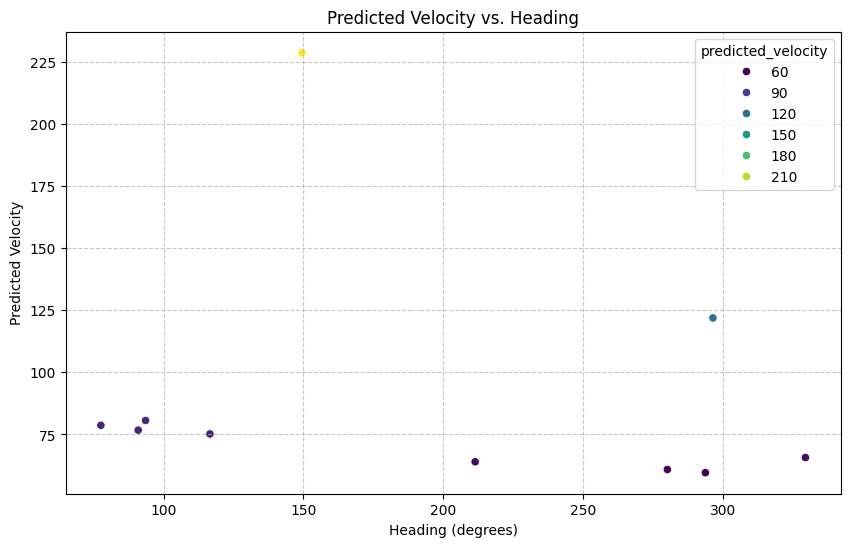

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'predictions_df' in locals() and not predictions_df.empty:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='heading', y='predicted_velocity', data=predictions_df, hue='predicted_velocity', palette='viridis')
    plt.title('Predicted Velocity vs. Heading')
    plt.xlabel('Heading (degrees)')
    plt.ylabel('Predicted Velocity')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print("predictions_df is not available or empty. Please ensure predictions are generated first.")

## 10. Flight Path Query & Visualization

Context: Queries historical data for a specific plane and plots the path.

Prompt: "Write a code block that:

Creates an input form field for CALLSIGN_TO_TRACK (defaulting to 'DAL339').

Queries the BigQuery table realtime_flight_data to retrieve the longitude, latitude, geo_altitude, and velocity for that callsign, ordered by timestamp.

Stores the result in a DataFrame.

Uses Seaborn to plot a line chart of Longitude vs. Latitude to visualize the flight path.

Mark the start position with a green dot and the end position with a red dot."

In [ ]:
#@title Enter the Callsign to Track
CALLSIGN_TO_TRACK = 'DAL339' #@param {type:"string"}

print(f"You chose to track flight with Callsign: {CALLSIGN_TO_TRACK}")

You chose to track flight with Callsign: DAL339


In [ ]:
from google.cloud import bigquery
import pandas as pd

bq_client = bigquery.Client(project=PROJECT_ID)

print(f"Fetching flight data for callsign: {CALLSIGN_TO_TRACK}...")

flight_path_query = f"""
SELECT
    sensor_timestamp,
    longitude,
    latitude,
    geo_altitude,
    velocity,
    heading,
    vertical_rate
FROM
    `{PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE_REALTIME}`
WHERE
    callsign = '{CALLSIGN_TO_TRACK}'
ORDER BY
    sensor_timestamp ASC
"""

flight_path_job = bq_client.query(flight_path_query)
flight_path_df = flight_path_job.to_dataframe()

if not flight_path_df.empty:
    print(f"Found {len(flight_path_df)} records for {CALLSIGN_TO_TRACK}.")
    display(flight_path_df.head())
else:
    print(f"No flight data found for callsign: {CALLSIGN_TO_TRACK}")

Fetching flight data for callsign: DAL339...
No flight data found for callsign: DAL339


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'flight_path_df' in locals() and not flight_path_df.empty:
    plt.figure(figsize=(12, 8))
    sns.lineplot(x='longitude', y='latitude', data=flight_path_df, marker='o', sort=False)
    plt.title(f'Flight Path for Callsign: {CALLSIGN_TO_TRACK}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Optionally, add start and end points
    if len(flight_path_df) > 0:
        plt.plot(flight_path_df['longitude'].iloc[0], flight_path_df['latitude'].iloc[0], 'go', markersize=10, label='Start') # Green circle for start
        plt.plot(flight_path_df['longitude'].iloc[-1], flight_path_df['latitude'].iloc[-1], 'ro', markersize=10, label='End') # Red circle for end

    plt.legend()
    plt.show()
else:
    print("No flight path data available to plot.")

No flight path data available to plot.


## 11. Classification Model Prediction

Context: Using a different model to classify if a plane is on the ground.

Prompt: "Write a script to perform classification using BigQuery ML.

Define a model name flight_on_ground_classifier.

Construct a SQL query that uses ML.PREDICT with this model.

The input data for the prediction should be the most recent 100 records from the realtime_flight_data table (selecting icao24, geo_altitude, and velocity).

Execute the query and display the classification results in a DataFrame."

In [ ]:
# Define the classification model name
CLASSIFICATION_MODEL_NAME = "flight_on_ground_classifier"

print(f"Classification Model: {CLASSIFICATION_MODEL_NAME}")

Classification Model: flight_on_ground_classifier


In [ ]:
from google.cloud import bigquery
import pandas as pd

bq_client = bigquery.Client(project=PROJECT_ID)

print(f"Running classification predictions using model: {CLASSIFICATION_MODEL_NAME}...")

# Construct the prediction query for the classification model
# We will use the latest data inserted into realtime_flight_data as input
classification_predict_query = f"""
SELECT
    * EXCEPT(predicted_on_ground_probs)
FROM
    ML.PREDICT(MODEL `{PROJECT_ID}.{BQ_DATASET}.{CLASSIFICATION_MODEL_NAME}`,
        (SELECT
            icao24,
            geo_altitude AS altitude, # Alias geo_altitude to altitude as required by model
            velocity
         FROM
            `{PROJECT_ID}.{BQ_DATASET}.{BQ_TABLE_REALTIME}`
         LIMIT 100 # Limit to avoid processing too much data for demonstration
         ))
"""

classification_predict_job = bq_client.query(classification_predict_query)
classification_predictions = classification_predict_job.result()

# Convert results to a Pandas DataFrame for easy viewing
classification_predictions_df = classification_predictions.to_dataframe()

if not classification_predictions_df.empty:
    print("\nBQML Classification Prediction Results (DataFrame Head):")
    display(classification_predictions_df.head())
else:
    print("No classification predictions were generated.")

Running classification predictions using model: flight_on_ground_classifier...

BQML Classification Prediction Results (DataFrame Head):


,predicted_on_ground,icao24,altitude,velocity
0,0,a25cdc,213.36,32.41
1,0,a299f9,152.40,32.56
2,0,acd27a,266.70,8.05
3,0,a4c0db,10713.72,225.78
4,0,aa4421,563.88,50.00


## Summary and Limitations

### What this demonstrates

The same underlying question, predicting flight behavior (delay, velocity, on-ground status) from live operational data, is solved three times with progressively less latency: a static historical batch load, a periodically-polled micro-batch pipeline, and a true event-driven streaming pipeline where each flight update is scored the moment it arrives. Part II's debugging narrative (Section: Analyze `on_ground` label diversity) is left in deliberately: the classification model initially failed because a `WHERE` clause filtering out `NULL` feature values also happened to filter out every `on_ground = TRUE` record, a realistic data engineering failure mode, diagnosed and fixed with a targeted diagnostic query rather than guessing.

### Limitations

1. **OpenSky's free-tier API** has rate limits and incomplete global coverage, live pulls in this pipeline are a sample of visible aircraft, not a complete picture of air traffic.
2. **The Part I historical model and the Part II/III live-data models are trained on different feature sets and data sources** (BTS on-time performance data vs. OpenSky state vectors), so their evaluation metrics aren't directly comparable to each other, each demonstrates the same ML workflow on the data available to that stage of the pipeline.
3. **The streaming pipeline (Part III) runs for a fixed timeout window** rather than continuously, it demonstrates the architecture end-to-end but isn't deployed as an always-on service (e.g., via Cloud Functions or Dataflow, as scoped in the original project plan).
4. **No monitoring or alerting** on data quality or model drift over time, both would be necessary for a production deployment of this pipeline.

### Tech Stack

Google Cloud (Cloud Storage, BigQuery, BigQuery ML, Pub/Sub) · Python (pandas, requests) · OpenSky Network API · Google Colab
